# Desafío NumPy: recomendador simple de taquerías

**Objetivo:** recomendar las 5 mejores taquerías cercanas a una ubicación dada, combinando:

- calificación promedio (`score`)
- distancia geográfica a la persona usuaria

No usamos todavía modelos como K-NN. La idea es construir una fórmula propia con vectores y operaciones de NumPy.

## 1. Importar librerías

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Cargar el dataset



El dataset original [MakeoverMonday 2026/W18 Best Tacos in San Diego](https://makeovermonday.vercel.app/dataset/2026w18-best-tacos-in-san-diego) en formato XLSX fue convertido a formato CSV y subido al [repo_oficial](https://github.com/UADE-Python-Data-Science/583433_repo_oficial/tree/main) en la carpeta /Datasets

In [2]:
# URL al dataset
url = "https://raw.githubusercontent.com/UADE-Python-Data-Science/583433_repo_oficial/refs/heads/main/Datasets/top_tacos_in_san_diego.csv"


In [3]:
# Cargamos el dataset usando el método read_csv de Pandas
df = pd.read_csv(url)
df.head(3)

,ID,Restaurant Name,Score,Latitude,Longitude,Review Snippet
0,SDT-001,Tacos El Gordo,4.6,32.6305,-117.0601,"""The adobada is non-negotiable. Authenticity a..."
1,SDT-002,The Taco Stand,4.7,32.8427,-117.2731,"""Handmade tortillas make the Al Pastor truly s..."
2,SDT-003,Las Cuatro Milpas,4.8,32.7003,-117.1431,"""Old school charm with the best chorizo in Bar..."


## 3.EDA

Usemos los primeros comandos y sumemos algunos más, aunque luego los estudiaremos en detalle

In [4]:
# Estructura del dataframe, variables, tipo de dato y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               50 non-null     object 
 1   Restaurant Name  50 non-null     object 
 2   Score            50 non-null     float64
 3   Latitude         50 non-null     float64
 4   Longitude        50 non-null     float64
 5   Review Snippet   50 non-null     object 
dtypes: float64(3), object(3)
memory usage: 2.5+ KB


In [5]:
# Medidas de posición central y dipersión
df["Score"].describe()

count    50.000000
mean      4.492000
std       0.165172
min       4.100000
25%       4.400000
50%       4.500000
75%       4.600000
max       4.800000
Name: Score, dtype: float64

### 3.1 Histograma
Tratemos de reproducir el Histograma de la infografía de MakeoverMondauy

<Axes: xlabel='Score', ylabel='Count'>

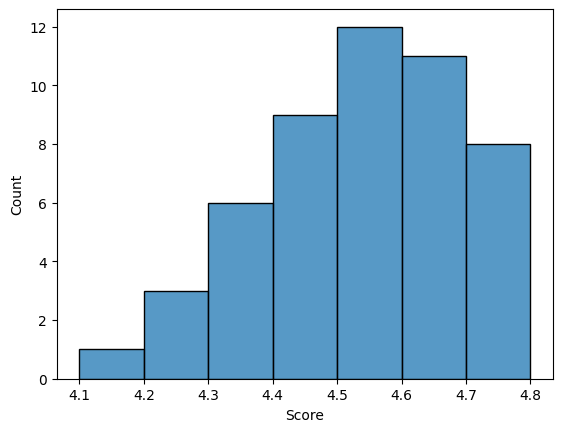

In [6]:
sns.histplot(data=df,
             x="Score",
             bins="auto")

### 3.2 Scatterplot
Normalmente usamos un scatterplot para estudiar la relación entre dos variables numéricas. En este caso particular, nuestras dos variables son coordenadas geográficas. Por eso, cada punto no representa una relación que queremos correlacionar, sino la ubicación de una taquería.

<Axes: xlabel='Longitude', ylabel='Latitude'>

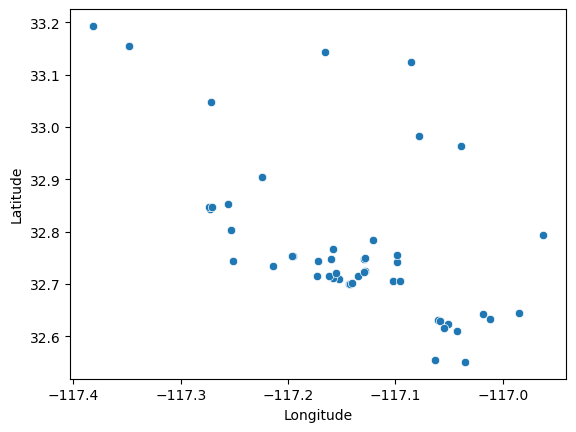

In [7]:
# Scatterplot usando la librería Seaborn (sns)
sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude"
)

### 3.3 Definimos un punto de interés: San Diego Zoo
[Website](https://zoo.sandiegozoo.org/)

* Address: 2920 Zoo Drive, San Diego, CA 92101
* Lat, Lon: (32.73418923826542, -117.14819173063803)

In [8]:
# Cargamos las coordenas en dos variables
ZOO_LATITUDE = 32.73418923826542
ZOO_LONGITUDE = -117.14819173063803

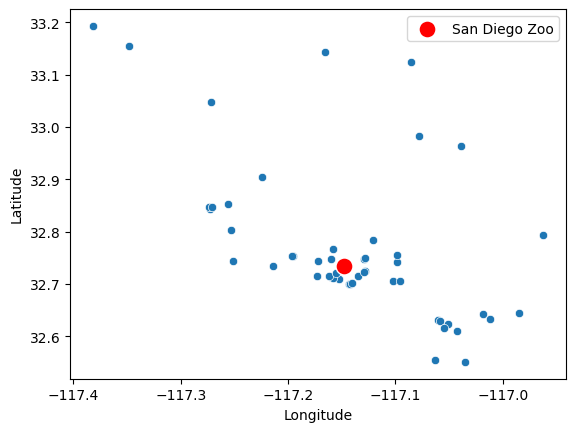

In [9]:
# Repetimos el Scatterplot anterior, 
# pero ahora sumamos las coordenadas del Zoo
sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude"
)

# Ubicación del usuario
sns.scatterplot(
    x=[ZOO_LONGITUDE],
    y=[ZOO_LATITUDE],
    color="red",
    s=150,
    label="San Diego Zoo"
)

plt.legend()
plt.show()

## 4. Desafío: usar distancia vectorial para generar la recomendación
Cómo podemos encontrar las 5 mejores taquerías más cercanas al punto de interés, es decir, las 5 mejores taquerias de San Diego en las inmediaciones del Zoo?

In [10]:
# En este Notebook, comenzamos cargando el dataset (archivo .CSV) en un dataframe df
print(f"Type of df: {type(df)}")

# Cuando accedemos a un atributo, por ejemplo, "Score", estamos trabajando con una Serie
print(f'Type of df["Score"]: {type(df["Score"])}')

Type of df: <class 'pandas.core.frame.DataFrame'>
Type of df["Score"]: <class 'pandas.core.series.Series'>


In [11]:
# Convertimos las Series de Pandas Score, Latitude y Longitude
# en arrays de NumPy
scores = df["Score"].to_numpy()
latitudes = df["Latitude"].to_numpy()
longitudes = df["Longitude"].to_numpy()


In [12]:
# Verificamos la conversión a ndarray
type(scores)

numpy.ndarray

## 5. Calcular distancias con NumPy

Muy probablemente hayan escuchado hablar de la "distancia euclídea".
<br>
Por ello, calculemos esa distancia sobre latitud y longitud:

$$distancia = \sqrt{(lat - user\_lat)^2 + (lon - user\_lon)^2}$$

No es perfecta para geografía real, pero es excelente para practicar vectores.

In [13]:
# Calculamos la distancia entre cada Taquería y el Zoo
distances = np.sqrt((latitudes - ZOO_LATITUDE)**2 + (longitudes - ZOO_LONGITUDE)**2)

In [14]:
distances

array([0.13605738, 0.16545894, 0.03426961, 0.02615843, 0.12577098,
       0.02452606, 0.16879398, 0.02370011, 0.19831514, 0.18560666,
       0.03416666, 0.03404595, 0.16282532, 0.10382153, 0.15906091,
       0.03042354, 0.02309078, 0.13864852, 0.14724691, 0.02212593,
       0.51513004, 0.15107782, 0.05433447, 0.05018385, 0.03387407,
       0.02179325, 0.2576288 , 0.4093726 , 0.3374807 , 0.05068964,
       0.05197338, 0.06003592, 0.01857425, 0.06600833, 0.21506323,
       0.25443694, 0.19549791, 0.02490149, 0.05709401, 0.02479156,
       0.46597123, 0.02475834, 0.16649369, 0.02376502, 0.01471205,
       0.15990226, 0.05458255, 0.39596943, 0.16877327, 0.1870095 ])

In [15]:
# Creamos una nueva variable (o atributo) en el dataframe a partir de las distancias calculadas
df["Distance"] = distances

# Mostramos el resultado
df[["Restaurant Name", "Score", "Distance"]].head()

,Restaurant Name,Score,Distance
0,Tacos El Gordo,4.6,0.136057
1,The Taco Stand,4.7,0.165459
2,Las Cuatro Milpas,4.8,0.034270
3,Lucha Libre Taco Shop,4.3,0.026158
4,Oscars Mexican Seafood,4.7,0.125771


## 6. Normalizar score y distancia

Como `score` y `distance` están en escalas distintas, los llevamos a una escala comparable entre 0 y 1.

- Para `score`: más alto es mejor.
- Para `distance`: más bajo es mejor, entonces invertimos la escala.

In [ ]:
score_norm = (scores - scores.min()) / (scores.max() - scores.min())

distance_norm = (distances - distances.min()) / (distances.max() - distances.min())
closeness_norm = 1 - distance_norm

print("Score normalizado:", score_norm)
print("Cercanía normalizada:", closeness_norm)

## 7. Crear una fórmula de recomendación

Propuesta inicial:

- 70% calidad
- 30% cercanía

La fórmula no es “la verdad”: es una decisión de diseño. Eso abre una linda discusión en clase.

In [ ]:
df.columns

In [ ]:
quality_weight = 0.70
closeness_weight = 0.30

recommendation_score = quality_weight * score_norm + closeness_weight * closeness_norm

df["Recommendation score"] = recommendation_score
df[["Restaurant Name", "Score", "Distance", "Recommendation score"]].head()

## 8. Obtener las mejores 5 taquerías

Usamos `np.argsort` para ordenar los índices según el puntaje de recomendación.

In [ ]:
df.sort_values(by="Recommendation score", ascending=False).head(5)

## 9. Actividad complementaria

Cambiar los pesos y observar qué pasa:

1. 90% calidad y 10% cercanía.
2. 50% calidad y 50% cercanía.
3. 30% calidad y 70% cercanía.

Preguntas:

- ¿Siempre gana la taquería con mejor score?
- ¿Cuándo empieza a importar más la distancia?
- ¿Qué recomendación sería mejor para una persona apurada?
- ¿Qué recomendación sería mejor para una persona dispuesta a viajar?